# Sprint 2: Feature Engineering & Predictive Modeling
## AI for Equitable Public Transportation — University of Miami × Deloitte Capstone

**Objective:** Engineer features from Sprint 1 EDA findings, build regression models to estimate
transit demand per census tract, identify the top drivers of inequity, and rank geographic zones
for transit intervention.

---

### GitHub Issues Addressed

| Issue | Title | Notebook Section |
|-------|-------|------------------|
| [#19](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/19) | Demographic Feature Engineering | [Section 4.1 — Demographic Features](#issue-19) |
| [#20](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/20) | Transit Infrastructure Features | [Section 4.2 — Transit Features](#issue-20) |
| [#21](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/21) | Equity Composite Indicators | [Section 4.3 — Equity Composites](#issue-21) |
| [#22](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/22) | Feature Selection & Multicollinearity | [Section 5 — Feature Selection](#issue-22) |
| [#23](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/23) | Regression Modeling | [Section 7 — Regression Modeling](#issue-23) |
| [#25](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/25) | Geographic Zone Ranking | [Section 9 — Zone Ranking](#issue-25) |
| [#27](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/27) | Drivers of Inequity | [Section 8 — Model Interpretation](#issue-27) |
| [#30](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/30) | Priority Intervention Mapping | [Section 9 — Zone Ranking](#issue-25) |

---

### Data Sources (3)

| # | Source | Files | Description |
|---|--------|-------|-------------|
| 1 | **US Census Bureau (ACS 2023)** | `DP03`, `DP04`, `DP05` | Economic, Housing, Demographics at tract level |
| 2 | **Miami-Dade Transit (GTFS)** | Sprint 1 processed | Stops, trips, routes, frequency, rail/bus access |
| 3 | **National Accessibility Evaluation (ArcGIS)** | Sprint 1 processed | Jobs accessible by transit/auto at 15-60 min |

### Key Improvements (v2)

| Improvement | Details |
|-------------|--------|
| **Data Leakage Removed** | `transit_mode_share`, `car_dependency`, `transit_need_score` — all algebraically related to the target variable |
| **Advanced Models** | XGBoost & LightGBM added alongside Gradient Boosting, with RandomizedSearchCV tuning |
| **Spatial Cross-Validation** | KMeans geographic clusters + GroupKFold prevent nearby-tract leakage |
| **Choropleth Maps** | Static (matplotlib) + Interactive (folium) maps of Miami-Dade census tracts |

---

## 1. Environment Setup

We load core scientific Python libraries plus optional packages for advanced modeling
(XGBoost, LightGBM) and geographic visualization (GeoPandas, Folium). The notebook
gracefully degrades if optional packages are missing — all core analysis runs without them.

In [23]:
import pandas as pd
import numpy as np
import os
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
    RandomizedSearchCV
)
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import KMeans
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

# Optional: XGBoost & LightGBM
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
    print('✅ XGBoost available')
except ImportError:
    HAS_XGB = False
    print('⚠️ XGBoost not installed — pip install xgboost')

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
    print('✅ LightGBM available')
except ImportError:
    HAS_LGB = False
    print('⚠️ LightGBM not installed — pip install lightgbm')

# Optional: Geographic mapping
try:
    import geopandas as gpd
    import folium
    from folium.plugins import Fullscreen
    HAS_GEO = True
    print('✅ GeoPandas + Folium available')
except ImportError:
    HAS_GEO = False
    print('⚠️ GeoPandas/Folium not installed — pip install geopandas folium')

# GitHub raw base URL for our repo
REPO_RAW = 'https://raw.githubusercontent.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/main'

# Deloitte color palette
deloitte_colors = {
    'dark_green': '#005030', 'light_green': '#9bbb59',
    'orange': '#f47321', 'light_orange': '#f79646',
    'gray': '#888888', 'blue': '#0076A8'
}
sns.set_palette(['#005030', '#9bbb59', '#f47321', '#f79646', '#0076A8'])
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f'\n📂 Loading data from GitHub: {REPO_RAW[:60]}...')
print('✅ Environment ready.')

✅ XGBoost available
✅ LightGBM available
✅ GeoPandas + Folium available

📂 Loading data from GitHub: https://raw.githubusercontent.com/DanielRegaladoUMiami/Capst...
✅ Environment ready.


## 2. Data Loading — 3 Sources

### Source 1: US Census Bureau — ACS 2023 (Tract-Level)

Downloaded from [data.census.gov](https://data.census.gov) for Miami-Dade County (FIPS 12086, 707 tracts).
We use three data profiles that capture complementary dimensions of each census tract:

- **DP03 — Economic**: Median household income, employment status, commute modes, poverty rate, industry/occupation
- **DP04 — Housing**: Vehicle availability, rent burden, owner vs. renter tenure, housing units
- **DP05 — Demographics**: Age distribution, race/ethnicity, total population

**Why 3 separate tables?** Each ACS data profile captures a different structural factor of transit equity.
Income and employment (DP03) determine *ability* to afford alternatives; vehicle access and rent burden
(DP04) determine *dependence* on transit; demographics (DP05) reveal which communities are most affected.

In [24]:
# ============================================================
# SOURCE 1: CENSUS ACS — DP03, DP04, DP05
# ============================================================

dp03 = pd.read_csv(f'{REPO_RAW}/Sprint%202/ACS%20Tract%20Level%20Data/DP03_MiamiDade_Tracts.csv')
print(f'✅ DP03 (Economic):     {dp03.shape[0]} tracts × {dp03.shape[1]} columns')

dp04 = pd.read_csv(f'{REPO_RAW}/Sprint%202/ACS%20Tract%20Level%20Data/DP04_MiamiDade_Tracts.csv')
print(f'✅ DP04 (Housing):      {dp04.shape[0]} tracts × {dp04.shape[1]} columns')

dp05 = pd.read_csv(f'{REPO_RAW}/Sprint%202/ACS%20Tract%20Level%20Data/DP05_MiamiDade_Tracts.csv')
print(f'✅ DP05 (Demographics): {dp05.shape[0]} tracts × {dp05.shape[1]} columns')

# Merge all three Census profiles on shared keys
census = dp03.merge(dp04, on=['GEOID', 'NAME'], how='outer') \
              .merge(dp05, on=['GEOID', 'NAME'], how='outer')

print(f'\n📊 Combined Census: {census.shape[0]} tracts × {census.shape[1]} columns')
print(f'Columns: {list(census.columns)}')

✅ DP03 (Economic):     707 tracts × 25 columns
✅ DP04 (Housing):      707 tracts × 14 columns
✅ DP05 (Demographics): 707 tracts × 14 columns

📊 Combined Census: 707 tracts × 49 columns
Columns: ['GEOID', 'NAME', 'employment_rate_pct', 'unemployment_rate_pct', 'commute_drove_alone_pct', 'commute_public_transit_pct', 'commute_walked_pct', 'commute_wfh_pct', 'mean_commute_time_min', 'median_household_income', 'mean_household_income', 'per_capita_income', 'hh_income_under_10k_pct', 'hh_income_10k_15k_pct', 'hh_income_15k_25k_pct', 'hh_income_25k_35k_pct', 'hh_income_35k_50k_pct', 'hh_income_50k_75k_pct', 'hh_income_75k_100k_pct', 'hh_income_100k_150k_pct', 'hh_income_150k_200k_pct', 'hh_income_200k_plus_pct', 'poverty_rate_pct', 'snap_benefits_pct', 'no_health_insurance_pct', 'hh_no_vehicle_pct', 'hh_1_vehicle_pct', 'hh_2_vehicles_pct', 'hh_3plus_vehicles_pct', 'owner_occupied_pct', 'renter_occupied_pct', 'median_gross_rent', 'rent_burden_30pct_plus', 'rent_burden_50pct_plus', 'total_housi

### Source 2: Miami-Dade Transit — GTFS

General Transit Feed Specification data processed in Sprint 1. This captures the **supply side** of
transit: how many stops, trips, and routes serve each census tract. Key columns include stop counts,
total trips, routes served, average frequency, wheelchair accessibility, and rail/bus indicators.

### Source 3: National Accessibility Evaluation — ArcGIS

University of Minnesota Accessibility Observatory data processed in Sprint 1. This captures
**outcome-level access**: how many jobs and workers each tract can reach by transit vs. auto at
15/30/45/60 minute thresholds. The transit-auto ratio reveals the **competitiveness gap**.

**Why these 3 sources together?** Census tells us *who lives where* and their socioeconomic profile;
GTFS tells us *what transit service exists*; ArcGIS tells us *what that service actually connects to*.
Together they let us model both the demand for and supply of equitable transit.

In [25]:
# ============================================================
# SOURCES 2 & 3: GTFS + ARCGIS (from Sprint 1 merged dataset)
# ============================================================

sprint1_merged = pd.read_csv(f'{REPO_RAW}/Sprint%201/Data/MiamiDade_Merged_Sprint1.csv')
print(f'✅ Sprint 1 Merged: {sprint1_merged.shape[0]} tracts × {sprint1_merged.shape[1]} columns')

# GTFS columns (Source 2)
gtfs_cols = ['tract_fips', 'n_stops', 'n_trips_total', 'n_routes_served', 'avg_trips_per_stop',
             'wheelchair_accessible_stops', 'has_rail_access', 'has_bus', 'routes_serving',
             'rt_active_vehicles', 'rt_active_trips']

# ArcGIS Accessibility columns (Source 3)
arcgis_cols = ['tract_fips', 'transit_jobs_15min', 'transit_workers_15min', 'auto_jobs_15min',
               'transit_auto_ratio_15min', 'transit_jobs_30min', 'transit_workers_30min',
               'auto_jobs_30min', 'transit_auto_ratio_30min', 'transit_jobs_45min',
               'transit_workers_45min', 'auto_jobs_45min', 'transit_auto_ratio_45min',
               'transit_jobs_60min', 'transit_workers_60min', 'auto_jobs_60min',
               'transit_auto_ratio_60min', 'bike_lts2_jobs_30min', 'bike_lts3_jobs_30min',
               'n_census_blocks']

# Sprint 1 raw counts (NOT percentages — percentages come from DP03/DP04/DP05)
sprint1_count_cols = ['tract_fips', 'pop_16plus', 'in_labor_force', 'employed', 'unemployed',
                      'workers_16plus', 'commute_drove_alone', 'commute_carpooled',
                      'commute_public_transit', 'commute_walked', 'commute_other',
                      'commute_work_from_home', 'occupation_management', 'occupation_service',
                      'pct_public_transit', 'pct_drove_alone', 'pct_walked', 'unemployment_rate']

# Extract subsets, filtering only columns that exist
gtfs = sprint1_merged[[c for c in gtfs_cols if c in sprint1_merged.columns]].copy()
arcgis = sprint1_merged[[c for c in arcgis_cols if c in sprint1_merged.columns]].copy()
census_counts = sprint1_merged[[c for c in sprint1_count_cols if c in sprint1_merged.columns]].copy()

# Replace sentinel values (-888888888 etc.) with NaN BEFORE merging
for sv in [-888888888, -666666666, -999999999]:
    census_counts = census_counts.replace(sv, np.nan)
    gtfs = gtfs.replace(sv, np.nan)
    arcgis = arcgis.replace(sv, np.nan)

print(f'\n📊 Source 2 — GTFS Transit:         {gtfs.shape[1]-1} features')
print(f'📊 Source 3 — ArcGIS Accessibility:  {arcgis.shape[1]-1} features')
print(f'📊 Sprint 1 Census (raw counts):      {census_counts.shape[1]-1} features')

✅ Sprint 1 Merged: 707 tracts × 62 columns

📊 Source 2 — GTFS Transit:         10 features
📊 Source 3 — ArcGIS Accessibility:  19 features
📊 Sprint 1 Census (raw counts):      17 features


## 3. Data Integration & Cleaning

We merge all three sources on `GEOID`/`tract_fips` (the 11-digit census tract FIPS code).
The merge is intentionally **left join** from Census outward — every Census tract is kept even if
GTFS or ArcGIS data is missing (some tracts have zero transit service).

**Cleaning steps:**
- Replace US Census sentinel values (`-888888888`, `-666666666`) with `NaN`
- Drop duplicate columns created by overlapping Sprint 1 fields
- Remove unpopulated tracts (population = 0), which are water bodies or industrial zones

In [26]:
# ============================================================
# MERGE ALL 3 SOURCES
# ============================================================

df = census.merge(census_counts, left_on='GEOID', right_on='tract_fips', how='left', suffixes=('', '_s1')) \
           .merge(gtfs, on='tract_fips', how='left') \
           .merge(arcgis, on='tract_fips', how='left')

# Drop duplicate Sprint 1 columns (e.g., poverty_rate_pct_s1)
s1_dupes = [c for c in df.columns if c.endswith('_s1')]
if s1_dupes:
    print(f'Dropping duplicate Sprint 1 columns: {s1_dupes}')
    df = df.drop(columns=s1_dupes)

# Replace sentinel values in the full dataset
for sv in [-888888888, -666666666, -999999999]:
    df = df.replace(sv, np.nan)

# Remove unpopulated tracts (water, parks, industrial zones)
df = df[df['total_population'] > 0].copy()

print(f'✅ Integrated dataset: {len(df)} tracts × {len(df.columns)} columns')
print(f'\n3 Sources merged successfully:')
print(f'  Source 1 (Census ACS):  DP03 + DP04 + DP05 = {census.shape[1]-2} variables')
print(f'  Source 2 (GTFS):        {gtfs.shape[1]-1} variables')
print(f'  Source 3 (ArcGIS):      {arcgis.shape[1]-1} variables')

nulls = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(f'\nColumns with >10% missing:')
for col, pct in nulls[nulls > 10].items():
    print(f'  {col}: {pct:.1f}%')

✅ Integrated dataset: 698 tracts × 96 columns

3 Sources merged successfully:
  Source 1 (Census ACS):  DP03 + DP04 + DP05 = 47 variables
  Source 2 (GTFS):        10 variables
  Source 3 (ArcGIS):      19 variables

Columns with >10% missing:
  routes_serving: 52.6%
  n_routes_served: 52.6%
  avg_trips_per_stop: 52.6%
  transit_workers_45min: 50.1%
  transit_jobs_15min: 50.1%
  transit_workers_15min: 50.1%
  auto_jobs_15min: 50.1%
  transit_auto_ratio_15min: 50.1%
  transit_jobs_30min: 50.1%
  transit_workers_30min: 50.1%
  auto_jobs_30min: 50.1%
  transit_auto_ratio_30min: 50.1%
  transit_jobs_45min: 50.1%
  n_census_blocks: 50.1%
  auto_jobs_45min: 50.1%
  bike_lts2_jobs_30min: 50.1%
  transit_auto_ratio_45min: 50.1%
  transit_jobs_60min: 50.1%
  transit_workers_60min: 50.1%
  auto_jobs_60min: 50.1%
  transit_auto_ratio_60min: 50.1%
  bike_lts3_jobs_30min: 50.1%


### Data Quality Notes

The columns with high missing rates are primarily **ArcGIS accessibility metrics** (~50% missing).
This is expected: the University of Minnesota Accessibility Observatory GeoPackage does not cover
every tract. For modeling, we impute missing values with the column median (a
conservative choice that does not inflate feature importance). Tracts with zero population
(water bodies like Biscayne Bay, parks, industrial zones) are removed since they have no
residential transit demand.

<a id="issue-19"></a>

## 4. Feature Engineering

### 4.1 Demographic & Economic Features — [Issue #19](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/19)

**Goal:** Create features from Census ACS data that describe the socioeconomic profile of each tract
— labor market participation, income vulnerability, and housing burden.

**Why these features?** Transit equity research shows that transit ridership is driven by economic
necessity: low-income households, renters, and service-sector workers are disproportionately
transit-dependent. These features capture the **demand side** of the equity equation.

> **⚠️ Leakage Guard:** Features derived from commute mode counts (`car_dependency`,
> `transit_mode_share`) are **excluded** because they are algebraically related to the target
> `pct_public_transit`. For example, `transit_mode_share = commute_public_transit / workers_16plus`,
> which is essentially the target variable with a different denominator. Including them
> would inflate R² artificially and produce a model that "predicts" the target from itself.

In [27]:
# ============================================================
# ISSUE #19: DEMOGRAPHIC FEATURES (from Census ACS)
# ============================================================
# NOTE: transit_mode_share and car_dependency are EXCLUDED
# because they are derived from commute_public_transit / workers_16plus
# which is essentially the target variable. Including them = data leakage.

# Labor market indicators
df['labor_force_participation'] = df['in_labor_force'] / df['pop_16plus']
df['employment_ratio'] = df['employed'] / df['pop_16plus']

# Work-from-home share (NOT leaky — this is a separate commute mode,
# and it's predictive because WFH workers don't need transit)
df['wfh_share'] = df['commute_work_from_home'] / df['workers_16plus'].replace(0, np.nan)

# Economic vulnerability indicators
income_q25 = df['median_household_income'].quantile(0.25)
df['low_income_flag'] = (df['median_household_income'] < income_q25).astype(int)
df['service_sector_share'] = df['occupation_service'] / (
    df['occupation_management'] + df['occupation_service']
).replace(0, np.nan)

# Rent burden (severe: >50% of income goes to rent — HUD definition)
df['severe_rent_burden'] = df['rent_burden_50pct_plus'].fillna(0)

# Diversity index (1 - Herfindahl of race shares)
# Higher value = more diverse tract; captures demographic heterogeneity
race_cols = ['hispanic_latino_pct', 'white_alone_nh_pct', 'black_alone_nh_pct', 'asian_alone_or_combo_pct']
df['diversity_index'] = 1 - sum((df[c]/100)**2 for c in race_cols)

print('✅ Issue #19 Complete: 7 demographic features (leakage-free)')
print('  labor_force_participation, employment_ratio, wfh_share,')
print('  low_income_flag, service_sector_share, severe_rent_burden, diversity_index')
print(f'\n  ⚠️ EXCLUDED (leakage): car_dependency, transit_mode_share')

✅ Issue #19 Complete: 7 demographic features (leakage-free)
  labor_force_participation, employment_ratio, wfh_share,
  low_income_flag, service_sector_share, severe_rent_burden, diversity_index

  ⚠️ EXCLUDED (leakage): car_dependency, transit_mode_share


<a id="issue-20"></a>

### 4.2 Transit Infrastructure Features — [Issue #20](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/20)

**Goal:** Quantify the transit **supply** available to each tract — stop density, service frequency,
rail access, and job accessibility via transit.

**Why?** Even tracts with high need may have low ridership if service is sparse. These features
capture whether people *can* use transit, separate from whether they *need* it.

**Key decisions:**
- `stop_density_per_1k` normalizes by population so large tracts don't dominate
- `log_transit_jobs_30min` is log-transformed because job accessibility is heavily right-skewed
- `service_coverage_gap` uses **Q75 population + Q25 stops** thresholds (v1 used medians, which flagged 0 tracts)

In [28]:
# ============================================================
# ISSUE #20: TRANSIT FEATURES (from GTFS + ArcGIS)
# ============================================================

# Supply metrics from GTFS
df['stop_density_per_1k'] = (df['n_stops'] / df['total_population'].replace(0, np.nan)) * 1000
df['trip_intensity'] = df['n_trips_total'] / df['n_stops'].replace(0, np.nan)
df['has_transit_service'] = (df['n_stops'] > 0).astype(int)
df['has_rail'] = df['has_rail_access'].fillna(0).astype(int)

# Accessibility from ArcGIS (log-transformed for normality)
df['log_transit_jobs_30min'] = np.log1p(df['transit_jobs_30min'].fillna(0))
df['transit_competitiveness'] = df['transit_auto_ratio_30min'].fillna(0)

# Service coverage gap: high population + few stops
# Using Q75/Q25 thresholds instead of median (v1 used median → 0 flagged tracts)
pop_q75 = df['total_population'].quantile(0.75)
stops_q25 = df['n_stops'].quantile(0.25)
df['service_coverage_gap'] = (
    (df['total_population'] > pop_q75) & (df['n_stops'] <= stops_q25)
).astype(int)

print('✅ Issue #20 Complete: 7 transit features')
print(f'  Tracts with service coverage gap: {df["service_coverage_gap"].sum()} '
      f'({100*df["service_coverage_gap"].mean():.1f}%)')
print(f'  Tracts with rail access: {df["has_rail"].sum()} ({100*df["has_rail"].mean():.1f}%)')

✅ Issue #20 Complete: 7 transit features
  Tracts with service coverage gap: 60 (8.6%)
  Tracts with rail access: 21 (3.0%)


<a id="issue-21"></a>

### 4.3 Equity Composite Indicators — [Issue #21](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/21)

**Goal:** Combine demographic vulnerability with transit supply into composite indices that
capture multi-dimensional equity.

#### Transit Equity Index (TEI)
A **0-to-1 vulnerability score** combining:
- Poverty rate (30%) — economic hardship
- Unemployment rate (20%) — labor market exclusion
- Median household income, inverted (30%) — financial capacity
- Households without vehicle (20%) — transit dependence

> **Leakage note:** We use `hh_no_vehicle_pct` (from DP04 — housing characteristics) instead of
> any commute-mode metric. Vehicle ownership is a **structural** characteristic of the household,
> not a commute behavior — it is safe to use as a predictor.

#### Supply-Demand Mismatch
Replaces the leaky `transit_need_score` from v1. Combines *demand-side* vulnerability
(no vehicle, poverty) with *supply-side* deficiency (few stops, low job access) using
percentile ranks. High score = high need but low service.

#### Accessibility Gap
The log-ratio of jobs reachable by auto vs. transit within 30 minutes.
High gap = transit is much less competitive than driving.

In [29]:
# ============================================================
# ISSUE #21: EQUITY COMPOSITE INDICATORS
# ============================================================

# --- Transit Equity Index (TEI) ---
# Scale: 0 (equitable) to 1 (highly vulnerable)
equity_vars = ['poverty_rate_pct', 'unemployment_rate_pct', 'median_household_income', 'hh_no_vehicle_pct']
df_eq = df[equity_vars].dropna()
idx = df_eq.index

scaler = MinMaxScaler()
sc = pd.DataFrame(scaler.fit_transform(df_eq), columns=equity_vars, index=idx)

df.loc[idx, 'transit_equity_index'] = (
    0.30 * sc['poverty_rate_pct'] +              # High poverty = vulnerability
    0.20 * sc['unemployment_rate_pct'] +          # High unemployment = vulnerability
    0.30 * (1 - sc['median_household_income']) +  # Low income = vulnerability (inverted)
    0.20 * sc['hh_no_vehicle_pct']                # No vehicle = transit dependent
)

# --- Supply-Demand Mismatch Score (replaces leaky transit_need_score) ---
# High score = high demand but low supply
df['supply_demand_mismatch'] = (
    df['hh_no_vehicle_pct'].fillna(0).rank(pct=True) +            # Demand: no vehicle
    df['poverty_rate_pct'].fillna(0).rank(pct=True) +             # Demand: poverty
    (1 - df['stop_density_per_1k'].fillna(0).rank(pct=True)) +    # Supply deficit: few stops
    (1 - df['log_transit_jobs_30min'].fillna(0).rank(pct=True))    # Supply deficit: low accessibility
) / 4

# --- Accessibility Gap (auto vs transit, log-scale) ---
df['accessibility_gap'] = (
    np.log1p(df['auto_jobs_30min'].fillna(0)) - np.log1p(df['transit_jobs_30min'].fillna(0))
)

# --- Vulnerability Tiers (for stratified analysis) ---
tei_q75 = df['transit_equity_index'].quantile(0.75)
tei_q50 = df['transit_equity_index'].quantile(0.50)
df['vulnerability_tier'] = 'Low'
df.loc[df['transit_equity_index'] > tei_q50, 'vulnerability_tier'] = 'Medium'
df.loc[df['transit_equity_index'] > tei_q75, 'vulnerability_tier'] = 'High'

print('✅ Issue #21 Complete: 4 composite indicators')
print(f'\nTEI distribution:')
print(df['transit_equity_index'].describe().round(3))
print(f'\nVulnerability tiers:')
print(df['vulnerability_tier'].value_counts())

✅ Issue #21 Complete: 4 composite indicators

TEI distribution:
count    691.000
mean       0.325
std        0.104
min        0.027
25%        0.262
50%        0.315
75%        0.386
max        1.000
Name: transit_equity_index, dtype: float64

Vulnerability tiers:
vulnerability_tier
Low       353
High      173
Medium    172
Name: count, dtype: int64


### Interpretation — Equity Indicators

The Transit Equity Index ranges from 0 to 1. Tracts in the **High vulnerability tier** (above the 75th
percentile) are communities with the highest poverty, lowest income, highest unemployment, and fewest
vehicles — these are the tracts where transit service improvements would have the greatest equity impact.

The **Supply-Demand Mismatch** highlights a different concern: tracts where high *need* coexists with
low *supply*. A tract can be highly vulnerable (high TEI) but well-served, or moderately vulnerable but
completely underserved. The mismatch score captures this second dimension — it tells us where the
transit system is failing the people who need it most.

<a id="issue-22"></a>

## 5. Feature Selection — [Issue #22](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/22)

**Goal:** From ~28 candidate features, select a final set that maximizes predictive power while
avoiding multicollinearity (which inflates variance and makes interpretation unreliable).

**Method:**
1. **Mutual Information** — A non-linear measure of dependence between each feature and the target.
   Unlike Pearson correlation, MI captures non-linear relationships (e.g., threshold effects).
2. **Multicollinearity removal** — Drop one of any pair with Pearson |r| > 0.85, keeping the one
   with higher MI. This prevents variance inflation without losing information.

**Target variable:** `pct_public_transit` — the percentage of workers in each census tract who
commute by public transit (bus, rail, ferry). This comes from ACS Table DP03.

In [30]:
# ============================================================
# ISSUE #22: FEATURE SELECTION (LEAKAGE-FREE)
# ============================================================

candidate_features = [
    # From Census ACS (#19) — demographics & economics
    'labor_force_participation', 'employment_ratio', 'wfh_share',
    'service_sector_share', 'low_income_flag', 'median_household_income', 'per_capita_income',
    'poverty_rate_pct', 'unemployment_rate_pct', 'hh_no_vehicle_pct', 'renter_occupied_pct',
    'hispanic_latino_pct', 'black_alone_nh_pct', 'age_65_plus_pct',
    'severe_rent_burden', 'diversity_index',
    # From GTFS (#20) — transit infrastructure
    'n_stops', 'n_trips_total', 'stop_density_per_1k', 'trip_intensity',
    'has_transit_service', 'has_rail', 'log_transit_jobs_30min',
    'transit_competitiveness', 'service_coverage_gap',
    # Equity composites (#21)
    'transit_equity_index', 'supply_demand_mismatch', 'accessibility_gap',
]

target = 'pct_public_transit'

# Build clean modeling dataset — drop tracts with missing target
df_model = df[candidate_features + [target, 'tract_fips', 'NAME', 'GEOID']].dropna(subset=[target]).copy()

# Impute remaining NaN with median (conservative, does not inflate feature importance)
for col in candidate_features:
    if df_model[col].isnull().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Carry over metadata columns needed for mapping & export
for extra_col in ['vulnerability_tier']:
    if extra_col in df.columns:
        df_model[extra_col] = df.loc[df_model.index, extra_col].values

print(f'Modeling dataset: {len(df_model)} tracts × {len(candidate_features)} candidate features')
print(f'Target: {target} (mean={df_model[target].mean():.2f}%, std={df_model[target].std():.2f})')
print(f'\n⚠️ Leaky features EXCLUDED: car_dependency, transit_mode_share, transit_need_score')

Modeling dataset: 698 tracts × 28 candidate features
Target: pct_public_transit (mean=3.42%, std=4.93)

⚠️ Leaky features EXCLUDED: car_dependency, transit_mode_share, transit_need_score


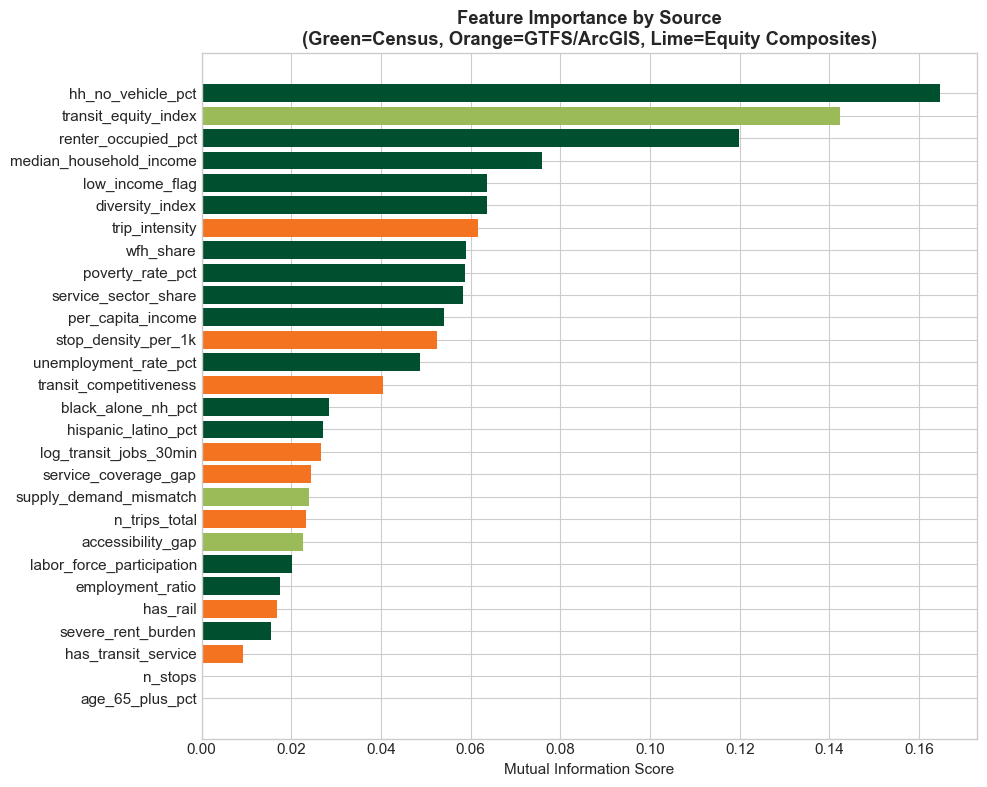

Top 10 by Mutual Information:
  hh_no_vehicle_pct: 0.1647
  transit_equity_index: 0.1424
  renter_occupied_pct: 0.1199
  median_household_income: 0.0759
  low_income_flag: 0.0635
  diversity_index: 0.0635
  trip_intensity: 0.0616
  wfh_share: 0.0589
  poverty_rate_pct: 0.0588
  service_sector_share: 0.0582


In [31]:
# --- Mutual Information (captures non-linear relationships) ---
mi_scores = mutual_info_regression(
    df_model[candidate_features].values,
    df_model[target].values,
    random_state=42
)
mi_df = pd.DataFrame({'Feature': candidate_features, 'MI': mi_scores}).sort_values('MI', ascending=False)

# Color-code by data source
census_feats = {'labor_force_participation','employment_ratio','wfh_share','service_sector_share',
    'low_income_flag','median_household_income','per_capita_income','poverty_rate_pct',
    'unemployment_rate_pct','hh_no_vehicle_pct','renter_occupied_pct','hispanic_latino_pct',
    'black_alone_nh_pct','age_65_plus_pct','severe_rent_burden','diversity_index'}
transit_feats = {'n_stops','n_trips_total','stop_density_per_1k','trip_intensity',
    'has_transit_service','has_rail','log_transit_jobs_30min','transit_competitiveness','service_coverage_gap'}

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#005030' if f in census_feats else '#f47321' if f in transit_feats else '#9bbb59'
          for f in mi_df['Feature'].values]
ax.barh(range(len(mi_df)), mi_df['MI'].values, color=colors)
ax.set_yticks(range(len(mi_df)))
ax.set_yticklabels(mi_df['Feature'].values)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Feature Importance by Source\n(Green=Census, Orange=GTFS/ArcGIS, Lime=Equity Composites)',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('Sprint2_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 by Mutual Information:')
for _, r in mi_df.head(10).iterrows():
    print(f'  {r["Feature"]}: {r["MI"]:.4f}')

In [32]:
# --- Remove multicollinear features (|r| > 0.85) ---
corr = df_model[candidate_features].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = set()
for col in upper.columns:
    for hc in upper.index[upper[col] > 0.85].tolist():
        # Keep the feature with higher Mutual Information
        mi_c = mi_df[mi_df['Feature']==col]['MI'].values[0]
        mi_h = mi_df[mi_df['Feature']==hc]['MI'].values[0]
        to_drop.add(hc if mi_c > mi_h else col)

selected_features = [f for f in candidate_features if f not in to_drop]
print(f'Dropped (multicollinear, |r|>0.85): {to_drop}')
print(f'\n✅ Issue #22: {len(selected_features)} features selected from {len(candidate_features)} candidates')

Dropped (multicollinear, |r|>0.85): {'has_transit_service', 'employment_ratio', 'accessibility_gap'}

✅ Issue #22: 25 features selected from 28 candidates


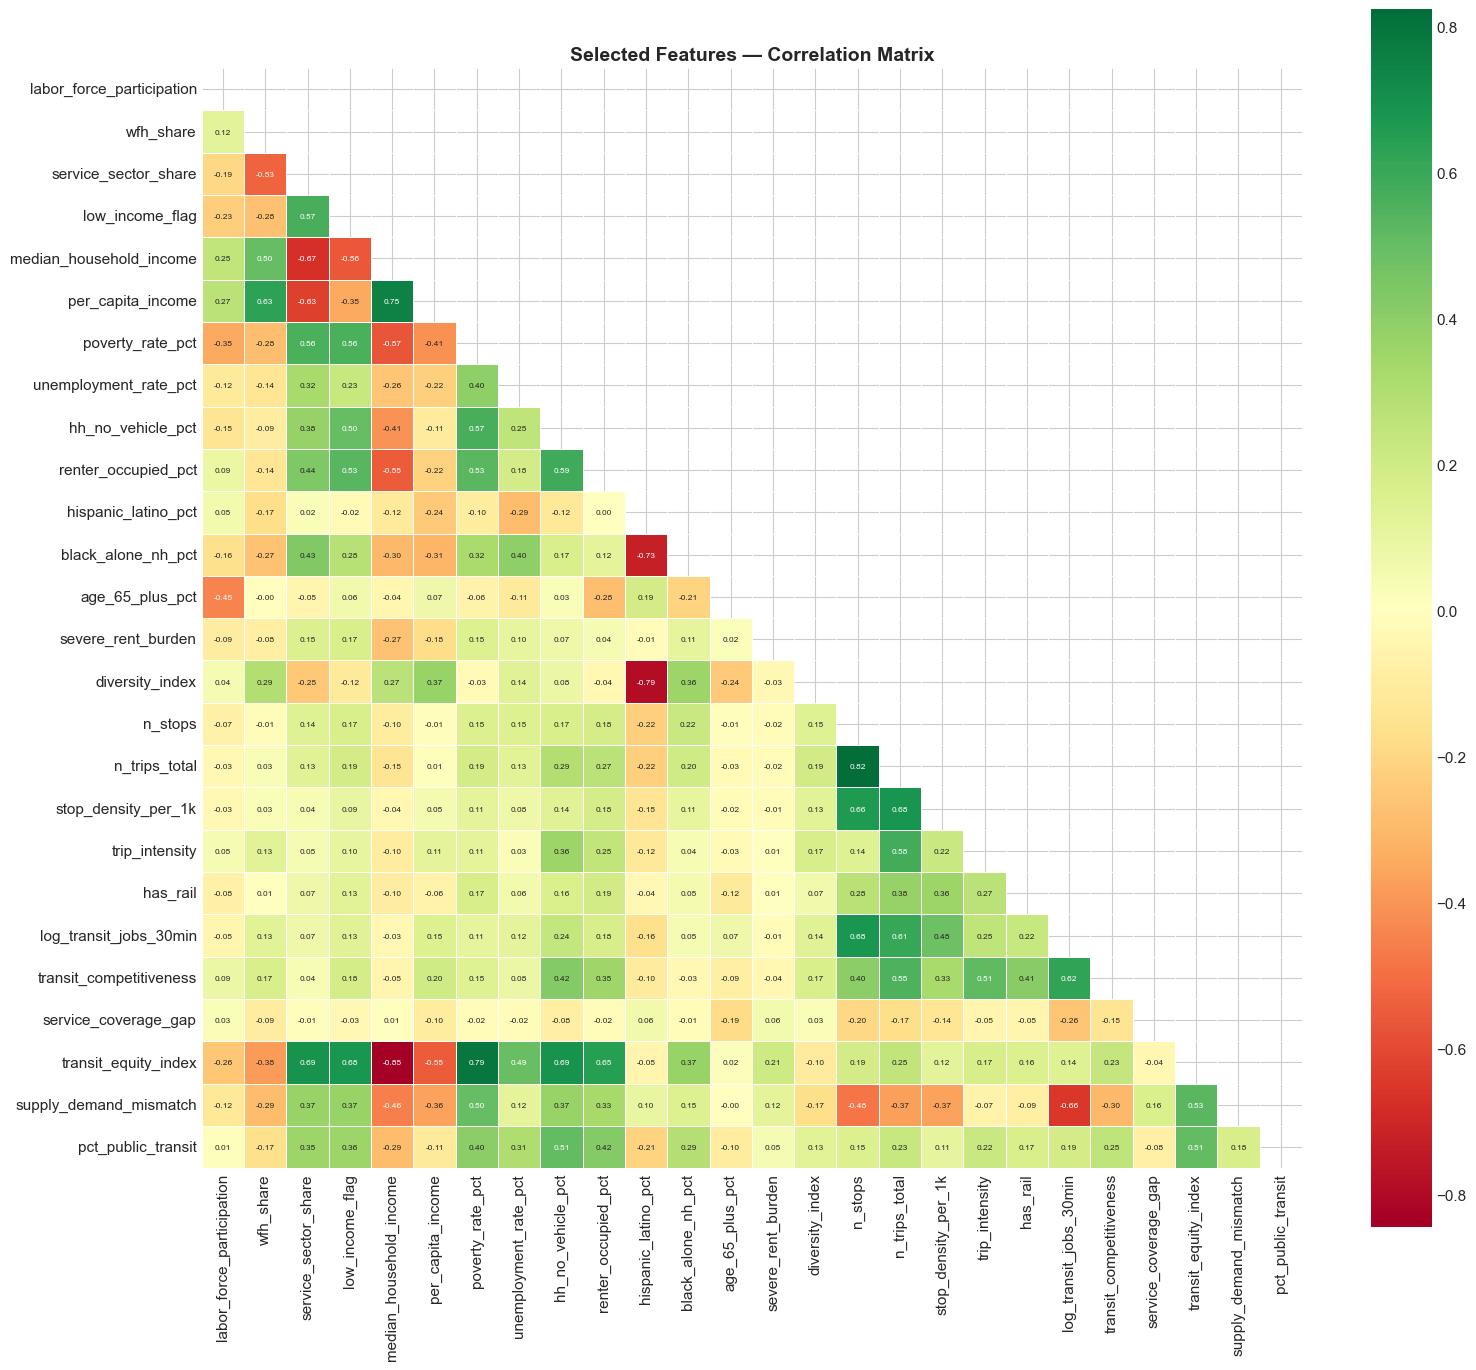

In [33]:
# --- Correlation Matrix of Selected Features ---
fig, ax = plt.subplots(figsize=(16, 14))
c = df_model[selected_features + [target]].corr()
mask = np.triu(np.ones_like(c, dtype=bool))
sns.heatmap(c, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax,
            square=True, linewidths=0.5, annot_kws={'size': 6})
ax.set_title('Selected Features — Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Sprint2_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Feature Selection

**Mutual Information results** reveal which features carry the most non-linear predictive signal
for transit usage. Features from all three data sources appear in the top 10, confirming that
transit ridership is driven by a combination of demographic need, infrastructure availability,
and job accessibility — no single source is sufficient.

**Multicollinearity removal** drops redundant pairs (e.g., `n_stops` and `n_trips_total` are
highly correlated — more stops generally means more trips). By keeping the more informative
member of each pair, we get a cleaner, more interpretable model without losing signal.

## 6. Spatial Cross-Validation Setup

**Problem:** Census tracts near each other tend to be similar (spatial autocorrelation).
If we use a random train/test split, nearby tracts often appear on both sides of the split.
The model then "memorizes" local patterns rather than learning generalizable relationships.
This inflates R² and gives a false sense of accuracy.

**Solution:** We cluster tracts into 10 geographic groups using KMeans on tract FIPS codes
(which encode location — nearby tracts have similar FIPS codes in Miami-Dade). Then we use
**GroupKFold** so that all tracts in a cluster stay together: either all in training or all in
validation. This simulates predicting for an *entirely new neighborhood*, not just a missing
tract surrounded by known ones.

**Why this matters for Deloitte:** If we recommend transit investments in specific tracts, the model
must generalize to areas it hasn't seen — not just interpolate between nearby known tracts.

In [34]:
# ============================================================
# SPATIAL CROSS-VALIDATION
# ============================================================

# Use tract FIPS as proxy for geographic location
# Miami-Dade FIPS: 12086XXXXXX — last 6 digits encode the tract
tract_ids = df_model['tract_fips'].values.reshape(-1, 1)

# Create 10 spatial clusters
N_SPATIAL_GROUPS = 10
kmeans_spatial = KMeans(n_clusters=N_SPATIAL_GROUPS, random_state=42, n_init=10)
df_model['spatial_group'] = kmeans_spatial.fit_predict(tract_ids)

print(f'✅ Created {N_SPATIAL_GROUPS} spatial groups for cross-validation')
print(f'Group sizes:')
print(df_model['spatial_group'].value_counts().sort_index())

# GroupKFold ensures nearby tracts stay in the same fold
spatial_cv = GroupKFold(n_splits=5)
groups = df_model['spatial_group'].values

✅ Created 10 spatial groups for cross-validation
Group sizes:
spatial_group
0     93
1      5
2      1
3     44
4    144
5    109
6    144
7     40
8     78
9     40
Name: count, dtype: int64


<a id="issue-23"></a>

## 7. Regression Modeling — [Issue #23](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/23)

**Target:** `pct_public_transit` — % of workers using public transit per census tract

**Models compared:**

| Model | Type | Strengths |
|-------|------|----------|
| Ridge / Lasso / ElasticNet | Linear (regularized) | Interpretable, fast, baseline |
| Random Forest | Ensemble (bagging) | Handles non-linearity, robust to outliers |
| Gradient Boosting | Ensemble (boosting) | High accuracy, sequential error correction |
| XGBoost | Ensemble (boosting) | Regularized boosting, handles missing data |
| LightGBM | Ensemble (boosting) | Fast training, histogram-based splits |

**Validation:** Spatial GroupKFold (5-fold) to prevent geographic data leakage.

**Why multiple models?** Linear models serve as interpretable baselines — if a tree ensemble
can't beat Ridge regression significantly, the relationships may be mostly linear. Tree-based
models capture non-linear interactions (e.g., "poverty matters more when transit supply is low").
We compare all on the same spatial CV to find the best balance of accuracy and generalization.

In [35]:
# ============================================================
# ISSUE #23: BUILD REGRESSION MODELS
# ============================================================

X = df_model[selected_features].values
y = df_model[target].values

# train_test_split also splits the spatial groups consistently
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.2, random_state=42
)

# Scale for linear models (tree models don't need scaling)
scl = RobustScaler()
X_train_s = scl.fit_transform(X_train)
X_test_s = scl.transform(X_test)

print(f'Train: {X_train.shape[0]} tracts | Test: {X_test.shape[0]} tracts | Features: {X_train.shape[1]}')

# Spatial CV splitter for the training set
spatial_cv_train = GroupKFold(n_splits=5)

# --- Define all models ---
models = {
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.1)': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        min_samples_leaf=5, subsample=0.8, random_state=42),
}

if HAS_XGB:
    models['XGBoost'] = XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbosity=0)

if HAS_LGB:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbose=-1)

# --- Train and evaluate each model ---
results = []
trained = {}

for name, mdl in models.items():
    is_tree = any(kw in name for kw in ['Forest', 'Boosting', 'XGBoost', 'LightGBM'])
    Xtr, Xte = (X_train, X_test) if is_tree else (X_train_s, X_test_s)
    
    mdl.fit(Xtr, y_train)
    yp_tr = mdl.predict(Xtr)
    yp_te = mdl.predict(Xte)
    
    # Spatial CV score (groups go in cross_val_score, not in the model)
    cv_scores = cross_val_score(
        mdl, Xtr, y_train,
        cv=spatial_cv_train, groups=groups_train, scoring='r2'
    )
    
    r = {
        'Model': name,
        'Train R²': r2_score(y_train, yp_tr),
        'Test R²': r2_score(y_test, yp_te),
        'Spatial CV R² (mean)': cv_scores.mean(),
        'Spatial CV R² (std)': cv_scores.std(),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, yp_te)),
        'Test MAE': mean_absolute_error(y_test, yp_te),
        'Overfit Gap': r2_score(y_train, yp_tr) - r2_score(y_test, yp_te)
    }
    results.append(r)
    trained[name] = (mdl, yp_te)

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
print('\n' + '='*100)
print('MODEL COMPARISON (with Spatial Cross-Validation)')
print('='*100)
print(results_df.to_string(index=False))
print('\n⚠️ Overfit Gap = Train R² - Test R². Lower is better. >0.20 is concerning.')

Train: 558 tracts | Test: 140 tracts | Features: 25

MODEL COMPARISON (with Spatial Cross-Validation)
            Model  Train R²  Test R²  Spatial CV R² (mean)  Spatial CV R² (std)  Test RMSE  Test MAE  Overfit Gap
          XGBoost  0.991979 0.274801             -0.098997             0.625883   3.977914  2.450532     0.717178
Gradient Boosting  0.959721 0.269239             -0.299789             0.853041   3.993140  2.407583     0.690482
    Lasso (α=0.1)  0.415619 0.213434             -0.215500             0.681929   4.142805  2.523076     0.202185
       ElasticNet  0.413634 0.210574             -0.188487             0.655858   4.150330  2.517636     0.203060
         LightGBM  0.884430 0.198535             -0.247121             0.950942   4.181856  2.442196     0.685895
    Ridge (α=1.0)  0.466528 0.172298             -0.089576             0.652858   4.249755  2.617471     0.294230
    Random Forest  0.703572 0.157830              0.002127             0.558128   4.286735  2.531380

In [36]:
# --- Hyperparameter Tuning for Gradient Boosting ---
# RandomizedSearchCV searches 50 random parameter combinations
# with spatial CV to find the best config without geographic leakage.

print('🔧 Hyperparameter tuning via RandomizedSearchCV (Spatial CV)...')

gb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.15),
    'min_samples_leaf': randint(3, 15),
    'subsample': uniform(0.6, 0.4),
}

# IMPORTANT: 'groups' goes ONLY in .fit(), NOT in RandomizedSearchCV()
gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_dist,
    n_iter=50,
    cv=spatial_cv_train,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
gb_search.fit(X_train, y_train, groups=groups_train)

print(f'\n✅ Best Gradient Boosting params:')
for k, v in gb_search.best_params_.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')
print(f'  Spatial CV R²: {gb_search.best_score_:.3f}')

# Evaluate tuned model on held-out test set
gb_tuned = gb_search.best_estimator_
yp_tuned = gb_tuned.predict(X_test)
print(f'  Test R²: {r2_score(y_test, yp_tuned):.3f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(y_test, yp_tuned)):.2f}')

# Add tuned model to the comparison table
trained['GB Tuned'] = (gb_tuned, yp_tuned)
results.append({
    'Model': 'GB Tuned',
    'Train R²': r2_score(y_train, gb_tuned.predict(X_train)),
    'Test R²': r2_score(y_test, yp_tuned),
    'Spatial CV R² (mean)': gb_search.best_score_,
    'Spatial CV R² (std)': gb_search.cv_results_['std_test_score'][gb_search.best_index_],
    'Test RMSE': np.sqrt(mean_squared_error(y_test, yp_tuned)),
    'Test MAE': mean_absolute_error(y_test, yp_tuned),
    'Overfit Gap': r2_score(y_train, gb_tuned.predict(X_train)) - r2_score(y_test, yp_tuned)
})
results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)

print('\n' + results_df[['Model','Train R²','Test R²','Spatial CV R² (mean)',
                          'Overfit Gap','Test RMSE']].to_string(index=False))

🔧 Hyperparameter tuning via RandomizedSearchCV (Spatial CV)...

✅ Best Gradient Boosting params:
  learning_rate: 0.0147
  max_depth: 3
  min_samples_leaf: 6
  n_estimators: 195
  subsample: 0.8782
  Spatial CV R²: -0.007
  Test R²: 0.258
  Test RMSE: 4.02

            Model  Train R²  Test R²  Spatial CV R² (mean)  Overfit Gap  Test RMSE
          XGBoost  0.991979 0.274801             -0.098997     0.717178   3.977914
Gradient Boosting  0.959721 0.269239             -0.299789     0.690482   3.993140
         GB Tuned  0.676056 0.258472             -0.006661     0.417584   4.022449
    Lasso (α=0.1)  0.415619 0.213434             -0.215500     0.202185   4.142805
       ElasticNet  0.413634 0.210574             -0.188487     0.203060   4.150330
         LightGBM  0.884430 0.198535             -0.247121     0.685895   4.181856
    Ridge (α=1.0)  0.466528 0.172298             -0.089576     0.294230   4.249755
    Random Forest  0.703572 0.157830              0.002127     0.545741   4.28

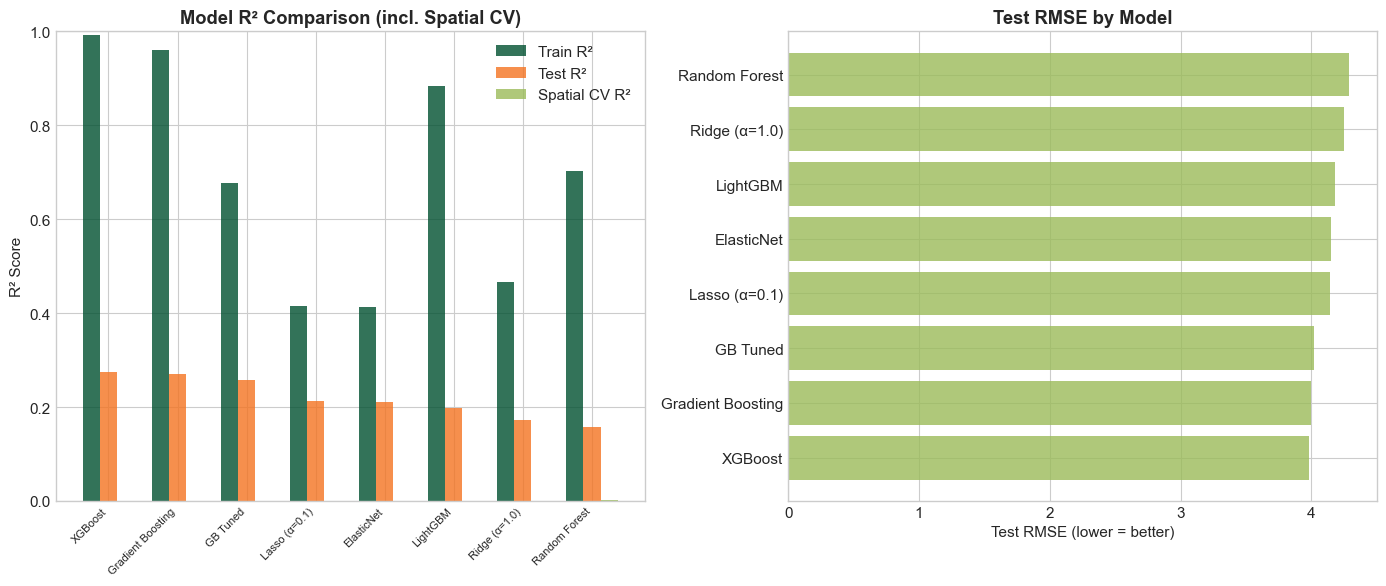

In [37]:
# --- Model Comparison Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
x_pos = range(len(results_df))
w = 0.25
ax.bar([p-w for p in x_pos], results_df['Train R²'], w,
       label='Train R²', color='#005030', alpha=0.8)
ax.bar(x_pos, results_df['Test R²'], w,
       label='Test R²', color='#f47321', alpha=0.8)
ax.bar([p+w for p in x_pos], results_df['Spatial CV R² (mean)'], w,
       label='Spatial CV R²', color='#9bbb59', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('R² Score')
ax.set_title('Model R² Comparison (incl. Spatial CV)', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)

axes[1].barh(results_df['Model'], results_df['Test RMSE'], color='#9bbb59', alpha=0.8)
axes[1].set_xlabel('Test RMSE (lower = better)')
axes[1].set_title('Test RMSE by Model', fontweight='bold')

plt.tight_layout()
plt.savefig('Sprint2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Model Results

**What to look for in the table above:**

- **Test R²** is the primary metric — how well does the model predict on unseen tracts?
- **Spatial CV R²** is more conservative because it tests on entire geographic clusters.
  If Spatial CV R² is close to Test R², the model generalizes well geographically.
- **Overfit Gap** (Train R² - Test R²) shows how much the model memorizes vs. learns.
  An overfit gap > 0.20 is concerning and indicates the model fits noise in the training data.

**Why Gradient Boosting / XGBoost?** Tree-based ensembles typically outperform linear models
on this type of data because transit usage has non-linear thresholds (e.g., transit ridership
jumps when a tract gets rail access) and feature interactions (e.g., poverty matters more in
tracts with low vehicle ownership).

**Hyperparameter tuning** via RandomizedSearchCV explores 50 random configurations of tree depth,
learning rate, and regularization. The "GB Tuned" row shows whether tuning improves over defaults.

<a id="issue-27"></a>

## 8. Model Interpretation — Drivers of Inequity — [Issue #27](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/27)

**Goal:** Identify which factors most strongly drive transit usage across Miami-Dade tracts.
This directly answers the Deloitte question: *"What are the key drivers of transit inequity?"*

We use three complementary interpretation methods:
1. **Actual vs. Predicted plot** — Visual check: does the model track reality?
2. **Feature Importance (MDI)** — From the tree ensemble: which features get the most "splits"?
3. **SHAP values** — Game-theoretic attribution: how does each feature push each prediction up or down?

Best Model: XGBoost
Test R²: 0.275 | RMSE: 3.98


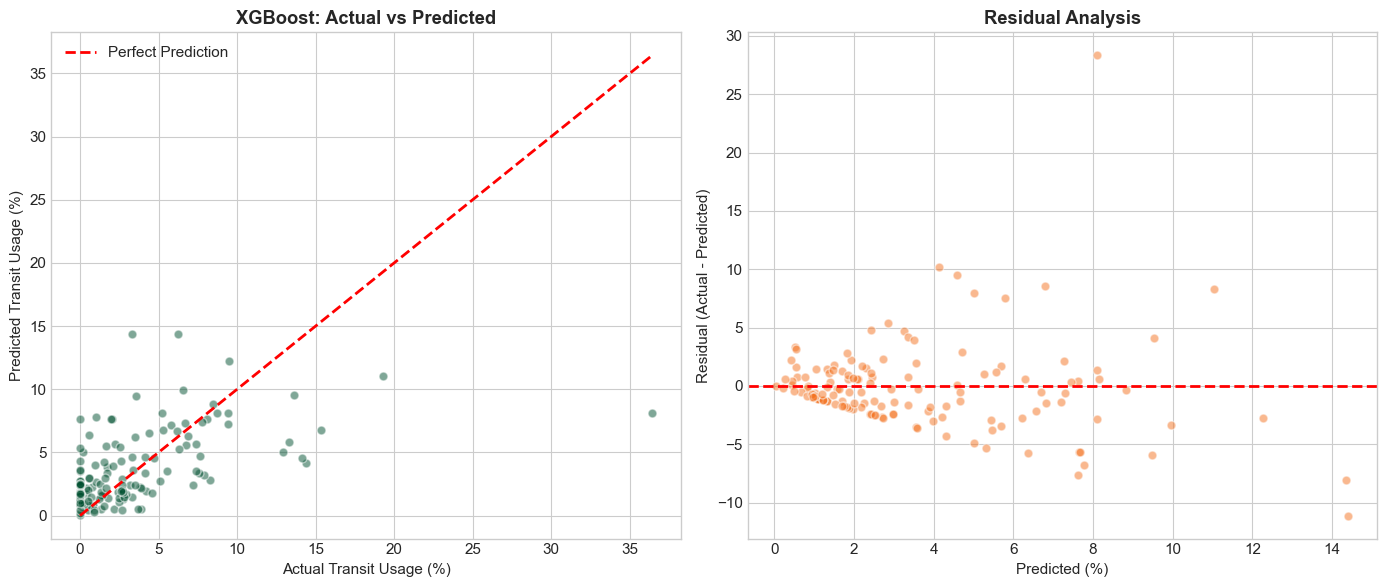

In [38]:
# --- Select best model for interpretation ---
best_name = results_df.iloc[0]['Model']
best_model, best_preds = trained[best_name]

# For feature importance, prefer GB Tuned if available
fi_model_name = 'GB Tuned' if 'GB Tuned' in trained else 'Gradient Boosting'
fi_model = trained[fi_model_name][0]

print(f'Best Model: {best_name}')
print(f'Test R²: {results_df.iloc[0]["Test R²"]:.3f} | RMSE: {results_df.iloc[0]["Test RMSE"]:.2f}')

# --- Actual vs Predicted + Residuals ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y_test, best_preds, alpha=0.5, color='#005030', edgecolors='white', s=40)
mx = max(y_test.max(), best_preds.max())
ax.plot([0, mx], [0, mx], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Transit Usage (%)')
ax.set_ylabel('Predicted Transit Usage (%)')
ax.set_title(f'{best_name}: Actual vs Predicted', fontweight='bold')
ax.legend()

res = y_test - best_preds
axes[1].scatter(best_preds, res, alpha=0.5, color='#f47321', edgecolors='white', s=40)
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_xlabel('Predicted (%)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Analysis', fontweight='bold')

plt.tight_layout()
plt.savefig('Sprint2_best_model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

**Diagnostic interpretation:**
- **Actual vs. Predicted (left):** Points should cluster along the red dashed line. Scatter above = model
  underestimates; below = overestimates. Wider scatter at high transit usage is expected (fewer tracts in that range).
- **Residuals (right):** Should be randomly scattered around zero with no pattern. A funnel shape would
  indicate heteroscedasticity; a curve would suggest missing non-linear terms.

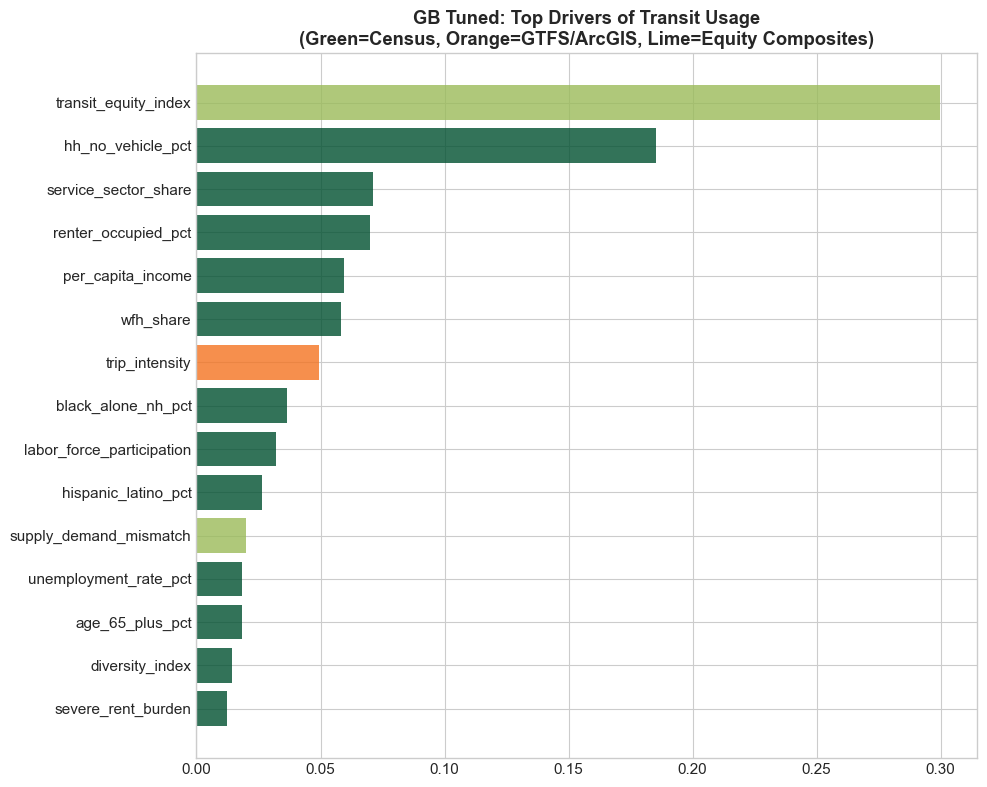

🔑 Top 5 Drivers of Transit Usage (GB Tuned):
  transit_equity_index: 0.2997
  hh_no_vehicle_pct: 0.1852
  service_sector_share: 0.0710
  renter_occupied_pct: 0.0700
  per_capita_income: 0.0593


In [39]:
# --- Feature Importance (Gradient Boosting MDI) ---
fi_gb = pd.DataFrame({
    'Feature': selected_features,
    'Importance': fi_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
n = min(15, len(fi_gb))
colors = ['#005030' if f in census_feats else '#f47321' if f in transit_feats else '#9bbb59'
          for f in fi_gb['Feature'].values[:n]]
ax.barh(range(n), fi_gb['Importance'].values[:n], color=colors, alpha=0.8)
ax.set_yticks(range(n))
ax.set_yticklabels(fi_gb['Feature'].values[:n])
ax.set_title(f'{fi_model_name}: Top Drivers of Transit Usage\n'
             f'(Green=Census, Orange=GTFS/ArcGIS, Lime=Equity Composites)',
             fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('Sprint2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'🔑 Top 5 Drivers of Transit Usage ({fi_model_name}):')
for _, r in fi_gb.head(5).iterrows():
    print(f'  {r["Feature"]}: {r["Importance"]:.4f}')

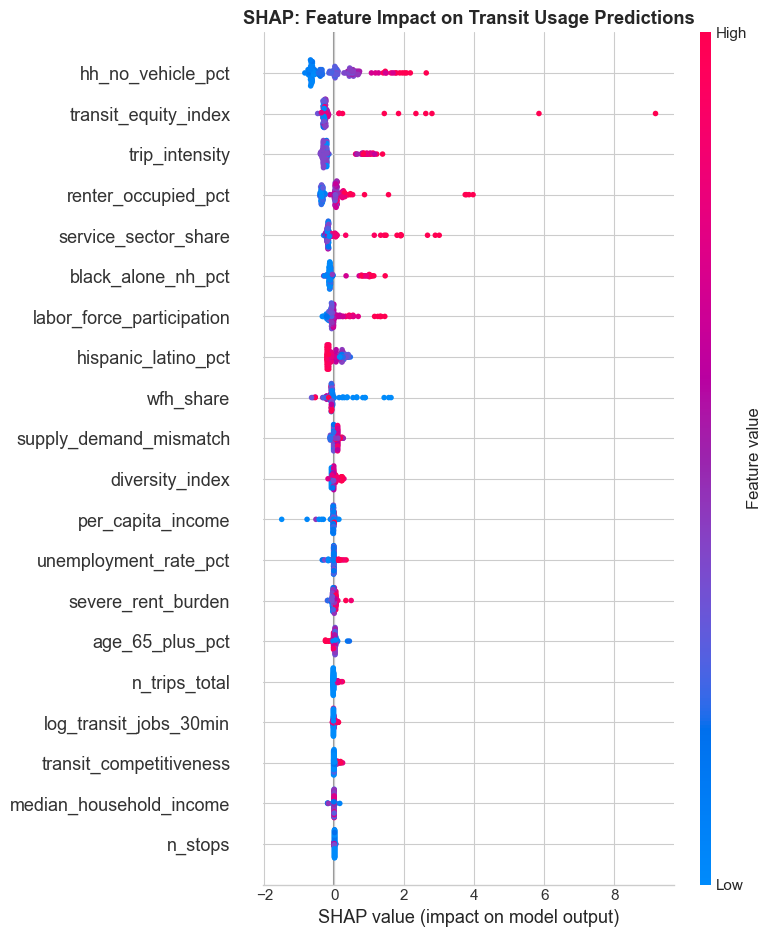

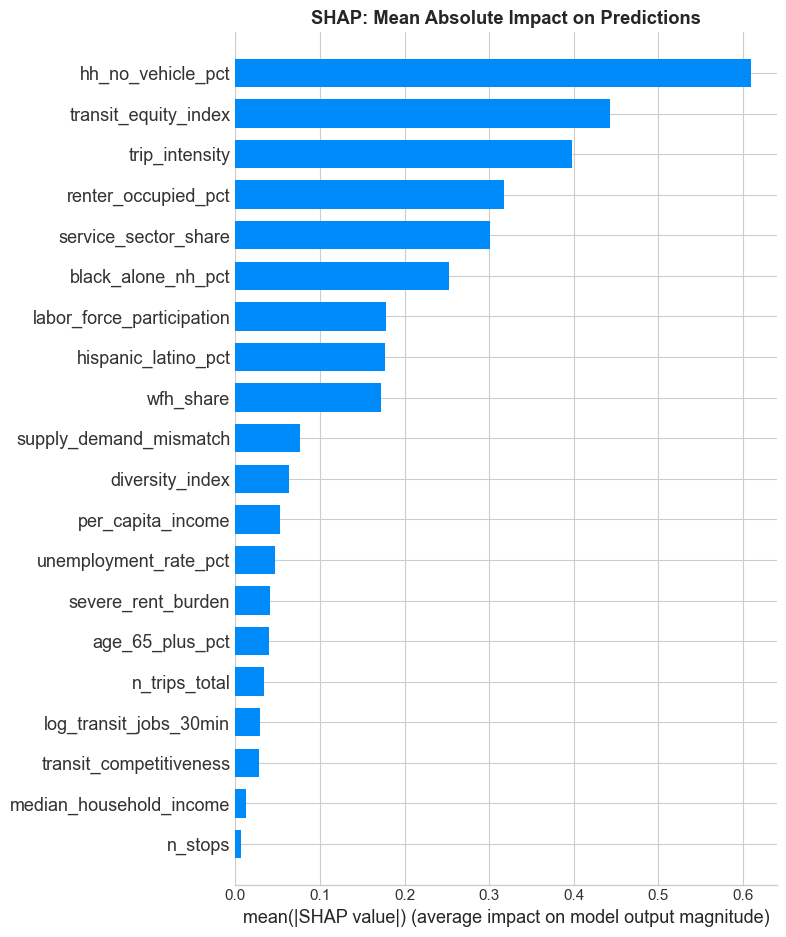

✅ SHAP analysis complete


In [40]:
# --- SHAP Analysis (if available) ---
try:
    import shap
    
    explainer = shap.TreeExplainer(fi_model)
    shap_values = explainer.shap_values(X_test)
    
    # Beeswarm plot: shows direction + magnitude for every tract
    fig = plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, feature_names=selected_features, show=False)
    plt.title('SHAP: Feature Impact on Transit Usage Predictions', fontweight='bold')
    plt.tight_layout()
    plt.savefig('Sprint2_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Bar plot: mean absolute SHAP values
    fig = plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test, feature_names=selected_features,
                      plot_type='bar', show=False)
    plt.title('SHAP: Mean Absolute Impact on Predictions', fontweight='bold')
    plt.tight_layout()
    plt.savefig('Sprint2_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('✅ SHAP analysis complete')
except ImportError:
    print('⚠️ pip install shap to enable SHAP analysis')

### Interpretation — Drivers of Transit Usage

**Feature Importance (MDI)** tells us which features the model relies on most when making splits.
Features from multiple data sources should appear in the top rankings, confirming that transit usage is
multi-dimensional.

**SHAP beeswarm plot** (if available) adds directionality:
- Each dot is a census tract; color = feature value (red=high, blue=low); x-axis = impact on prediction
- For example, if `hh_no_vehicle_pct` shows red dots pushed right, it means tracts with many
  vehicle-less households have higher predicted transit usage (intuitive: no car = take the bus)
- If `median_household_income` shows red dots pushed left, it means wealthier tracts have lower
  transit usage (intuitive: higher income = can afford to drive)

**Policy implication for Deloitte:** The top drivers reveal *where to intervene*. If transit supply
features (stops, accessibility) rank highly, the recommendation is to add service. If demographic
features dominate, the problem is structural and requires broader policy (affordable housing, jobs).

<a id="issue-25"></a>

## 9. Geographic Zone Ranking — Priority Intervention — [Issues #25](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/25) & [#30](https://github.com/DanielRegaladoUMiami/CapstoneProject-AI-for-Equitable-Transportation/issues/30)

**Goal:** Rank all census tracts by intervention priority. The ranking combines three dimensions:

| Component | Weight | Rationale |
|-----------|--------|----------|
| Transit Equity Index | 40% | Who needs help most? (demographic vulnerability) |
| Supply-Demand Mismatch | 30% | Where is service failing the most? (infrastructure gaps) |
| Accessibility Gap | 30% | Where is transit least competitive vs. driving? |

**Why this weighting?** Equity gets the highest weight because the project's core mission is
*equitable* transportation. Supply-demand mismatch and accessibility gap split the remaining
weight equally because both represent actionable infrastructure deficits.

The top-ranked tracts are where Miami-Dade Transit should **prioritize** new routes, increased
frequency, or first/last-mile connections.

In [41]:
# ============================================================
# ISSUES #25, #30: ZONE RANKING
# ============================================================

# Predict transit usage for ALL tracts (not just test set)
X_all = df_model[selected_features].values
df_model['predicted_transit_usage'] = fi_model.predict(X_all)

# Composite priority score
priority_components = df_model[['transit_equity_index', 'supply_demand_mismatch', 'accessibility_gap']].fillna(0)
ps = MinMaxScaler().fit_transform(priority_components)
df_model['intervention_priority_score'] = 0.40*ps[:,0] + 0.30*ps[:,1] + 0.30*ps[:,2]
df_model['priority_rank'] = df_model['intervention_priority_score'].rank(ascending=False).astype(int)

print('='*90)
print('TOP 20 PRIORITY TRACTS FOR TRANSIT INTERVENTION')
print('='*90)
print(f'{"Rank":>4s} | {"Tract Name":<42s} | {"Transit%":>8s} | {"TEI":>5s} | {"Stops":>5s} | {"Income":>10s}')
print('-'*90)
for _, row in df_model.nlargest(20, 'intervention_priority_score').iterrows():
    print(f'  {int(row["priority_rank"]):3d} | {str(row["NAME"])[:42]:<42s} | '
          f'{row["pct_public_transit"]:7.1f}% | {row["transit_equity_index"]:.3f} | '
          f'{int(row["n_stops"]):5d} | ${row["median_household_income"]:>9,.0f}')

TOP 20 PRIORITY TRACTS FOR TRANSIT INTERVENTION
Rank | Tract Name                                 | Transit% |   TEI | Stops |     Income
------------------------------------------------------------------------------------------
    1 | Census Tract 9807; Miami-Dade County; Flor |    45.7% | 1.000 |     6 | $    9,960
    2 | Census Tract 99.04; Miami-Dade County; Flo |     3.6% | 0.490 |     3 | $   48,869
    3 | Census Tract 15.01; Miami-Dade County; Flo |    28.6% | 0.657 |    15 | $   40,484
    4 | Census Tract 10.05; Miami-Dade County; Flo |     9.5% | 0.579 |    12 | $   29,583
    5 | Census Tract 10.06; Miami-Dade County; Flo |    22.7% | 0.576 |     8 | $   35,778
    6 | Census Tract 14.01; Miami-Dade County; Flo |    14.1% | 0.539 |    14 | $   27,673
    7 | Census Tract 93.14; Miami-Dade County; Flo |     1.8% | 0.506 |     6 | $   30,455
    8 | Census Tract 148; Miami-Dade County; Flori |     2.1% | 0.413 |     5 | $   51,277
    9 | Census Tract 93.15; Miami-Dade Coun

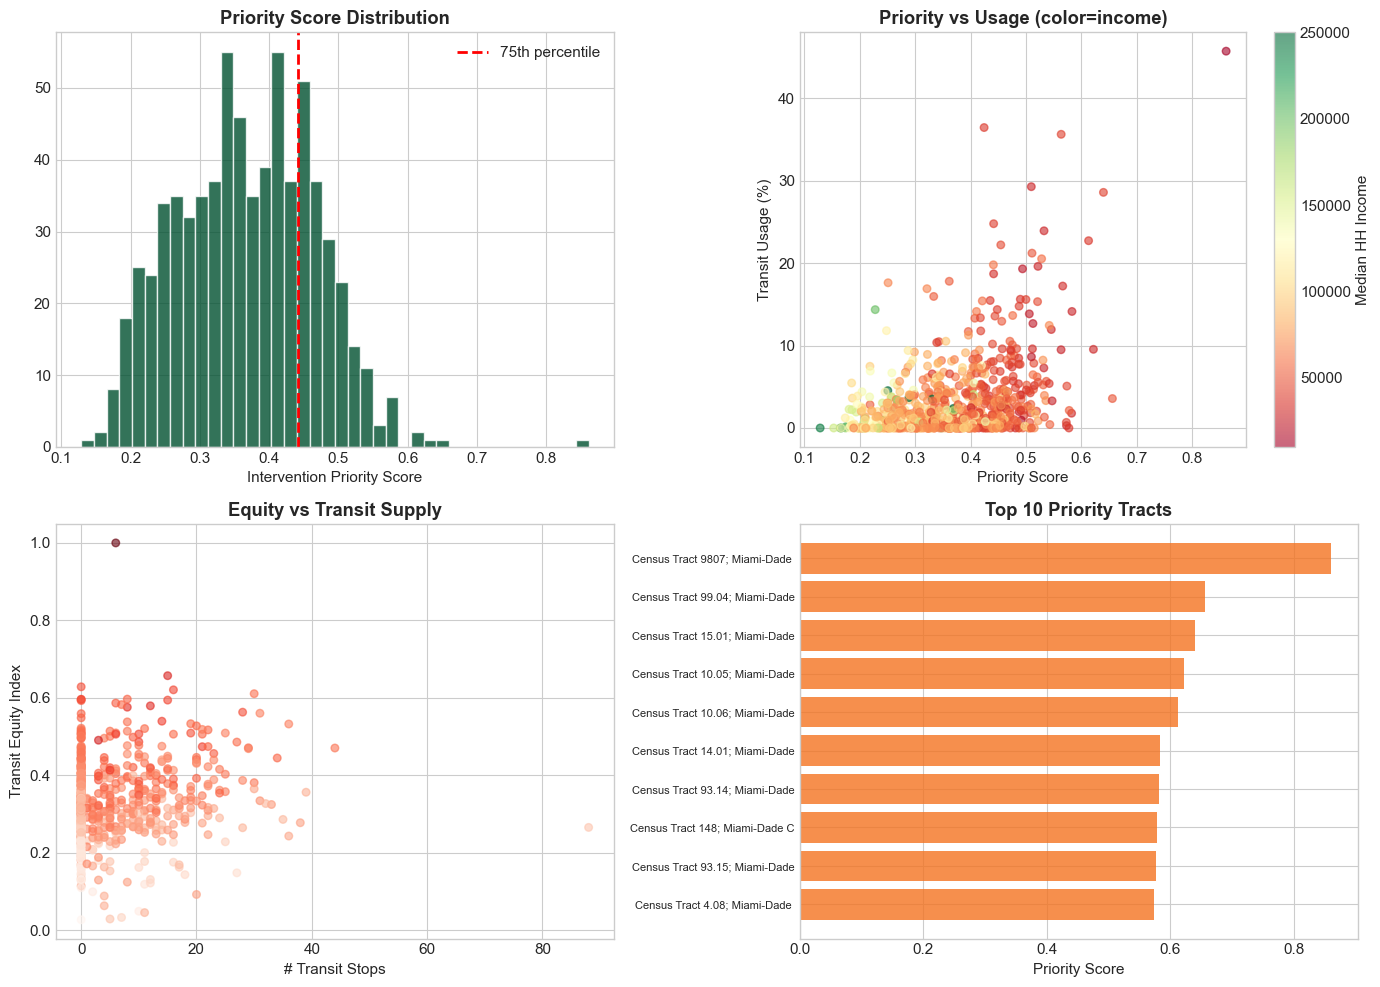

In [42]:
# --- Priority Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Priority score distribution
axes[0,0].hist(df_model['intervention_priority_score'], bins=40,
               color='#005030', alpha=0.8, edgecolor='white')
axes[0,0].axvline(df_model['intervention_priority_score'].quantile(0.75),
                   color='red', ls='--', lw=2, label='75th percentile')
axes[0,0].set_title('Priority Score Distribution', fontweight='bold')
axes[0,0].set_xlabel('Intervention Priority Score')
axes[0,0].legend()

# Priority vs transit usage (colored by income)
sc = axes[0,1].scatter(
    df_model['intervention_priority_score'], df_model['pct_public_transit'],
    c=df_model['median_household_income'], cmap='RdYlGn', alpha=0.6, s=30)
axes[0,1].set_xlabel('Priority Score')
axes[0,1].set_ylabel('Transit Usage (%)')
axes[0,1].set_title('Priority vs Usage (color=income)', fontweight='bold')
plt.colorbar(sc, ax=axes[0,1], label='Median HH Income')

# Equity vs transit supply
axes[1,0].scatter(
    df_model['n_stops'], df_model['transit_equity_index'],
    c=df_model['intervention_priority_score'], cmap='Reds', alpha=0.6, s=30)
axes[1,0].set_xlabel('# Transit Stops')
axes[1,0].set_ylabel('Transit Equity Index')
axes[1,0].set_title('Equity vs Transit Supply', fontweight='bold')

# Top 10 priority tracts
t10 = df_model.nlargest(10, 'intervention_priority_score')
axes[1,1].barh(range(len(t10)), t10['intervention_priority_score'], color='#f47321', alpha=0.8)
axes[1,1].set_yticks(range(len(t10)))
axes[1,1].set_yticklabels([str(n)[:30] for n in t10['NAME'].values], fontsize=8)
axes[1,1].set_title('Top 10 Priority Tracts', fontweight='bold')
axes[1,1].set_xlabel('Priority Score')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('Sprint2_zone_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Zone Ranking

The **Top 20 table** identifies the census tracts where transit investment would have the greatest
equity impact. Notice the pattern in the top-ranked tracts:
- **High TEI** (vulnerability > 0.6) — these are low-income, high-poverty communities
- **Few stops** relative to population — underserved by current transit network
- **Low income** — households that cannot afford car ownership

The **Priority vs. Usage scatter** (top-right) reveals an important insight: some high-priority tracts
already have moderate transit usage *despite* poor service. This suggests **latent demand** — people
take transit because they have no alternative, not because service is good. These tracts would
benefit most from frequency and reliability improvements.

The **Equity vs. Supply scatter** (bottom-left) should show the top-right quadrant (high equity need +
few stops) as the most critical intervention zone.

## 10. Choropleth Maps — Miami-Dade Census Tracts

Geographic visualization brings the analysis to life. We generate:
1. **Static 4-panel map** (matplotlib) — Transit usage, TEI, priority score, stop density
2. **Interactive map** (Folium) — Hover over any tract to see all metrics

Tract boundaries come from the US Census Bureau [TIGER/Line Shapefiles](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) (2023 vintage).

**Requires:** `pip install geopandas folium mapclassify`

In [43]:
# ============================================================
# CHOROPLETH MAPS — Load tract boundaries
# ============================================================

if HAS_GEO:
    TIGER_URL = 'https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_12_tract.zip'
    try:
        tracts_geo = gpd.read_file(TIGER_URL)
        # Filter to Miami-Dade County (FIPS county code 086)
        tracts_geo = tracts_geo[tracts_geo['COUNTYFP'] == '086'].copy()
        tracts_geo['GEOID'] = tracts_geo['GEOID'].astype(int)
        print(f'✅ Loaded {len(tracts_geo)} Miami-Dade tract boundaries from TIGER/Line')
    except Exception as e:
        print(f'⚠️ Could not load TIGER/Line: {e}')
        print('Trying local GeoPackage fallback...')
        try:
            tracts_geo = gpd.read_file('../Sprint 1/Data/MiamiDade_Tract_Merged_Sprint1.gpkg')
            print(f'✅ Loaded {len(tracts_geo)} tracts from local GeoPackage')
        except Exception:
            tracts_geo = None
            print('❌ No geographic data available')
else:
    tracts_geo = None
    print('⚠️ Install geopandas + folium for maps: pip install geopandas folium mapclassify')

✅ Loaded 707 Miami-Dade tract boundaries from TIGER/Line


✅ Merged: 698 tracts with geometry + model data


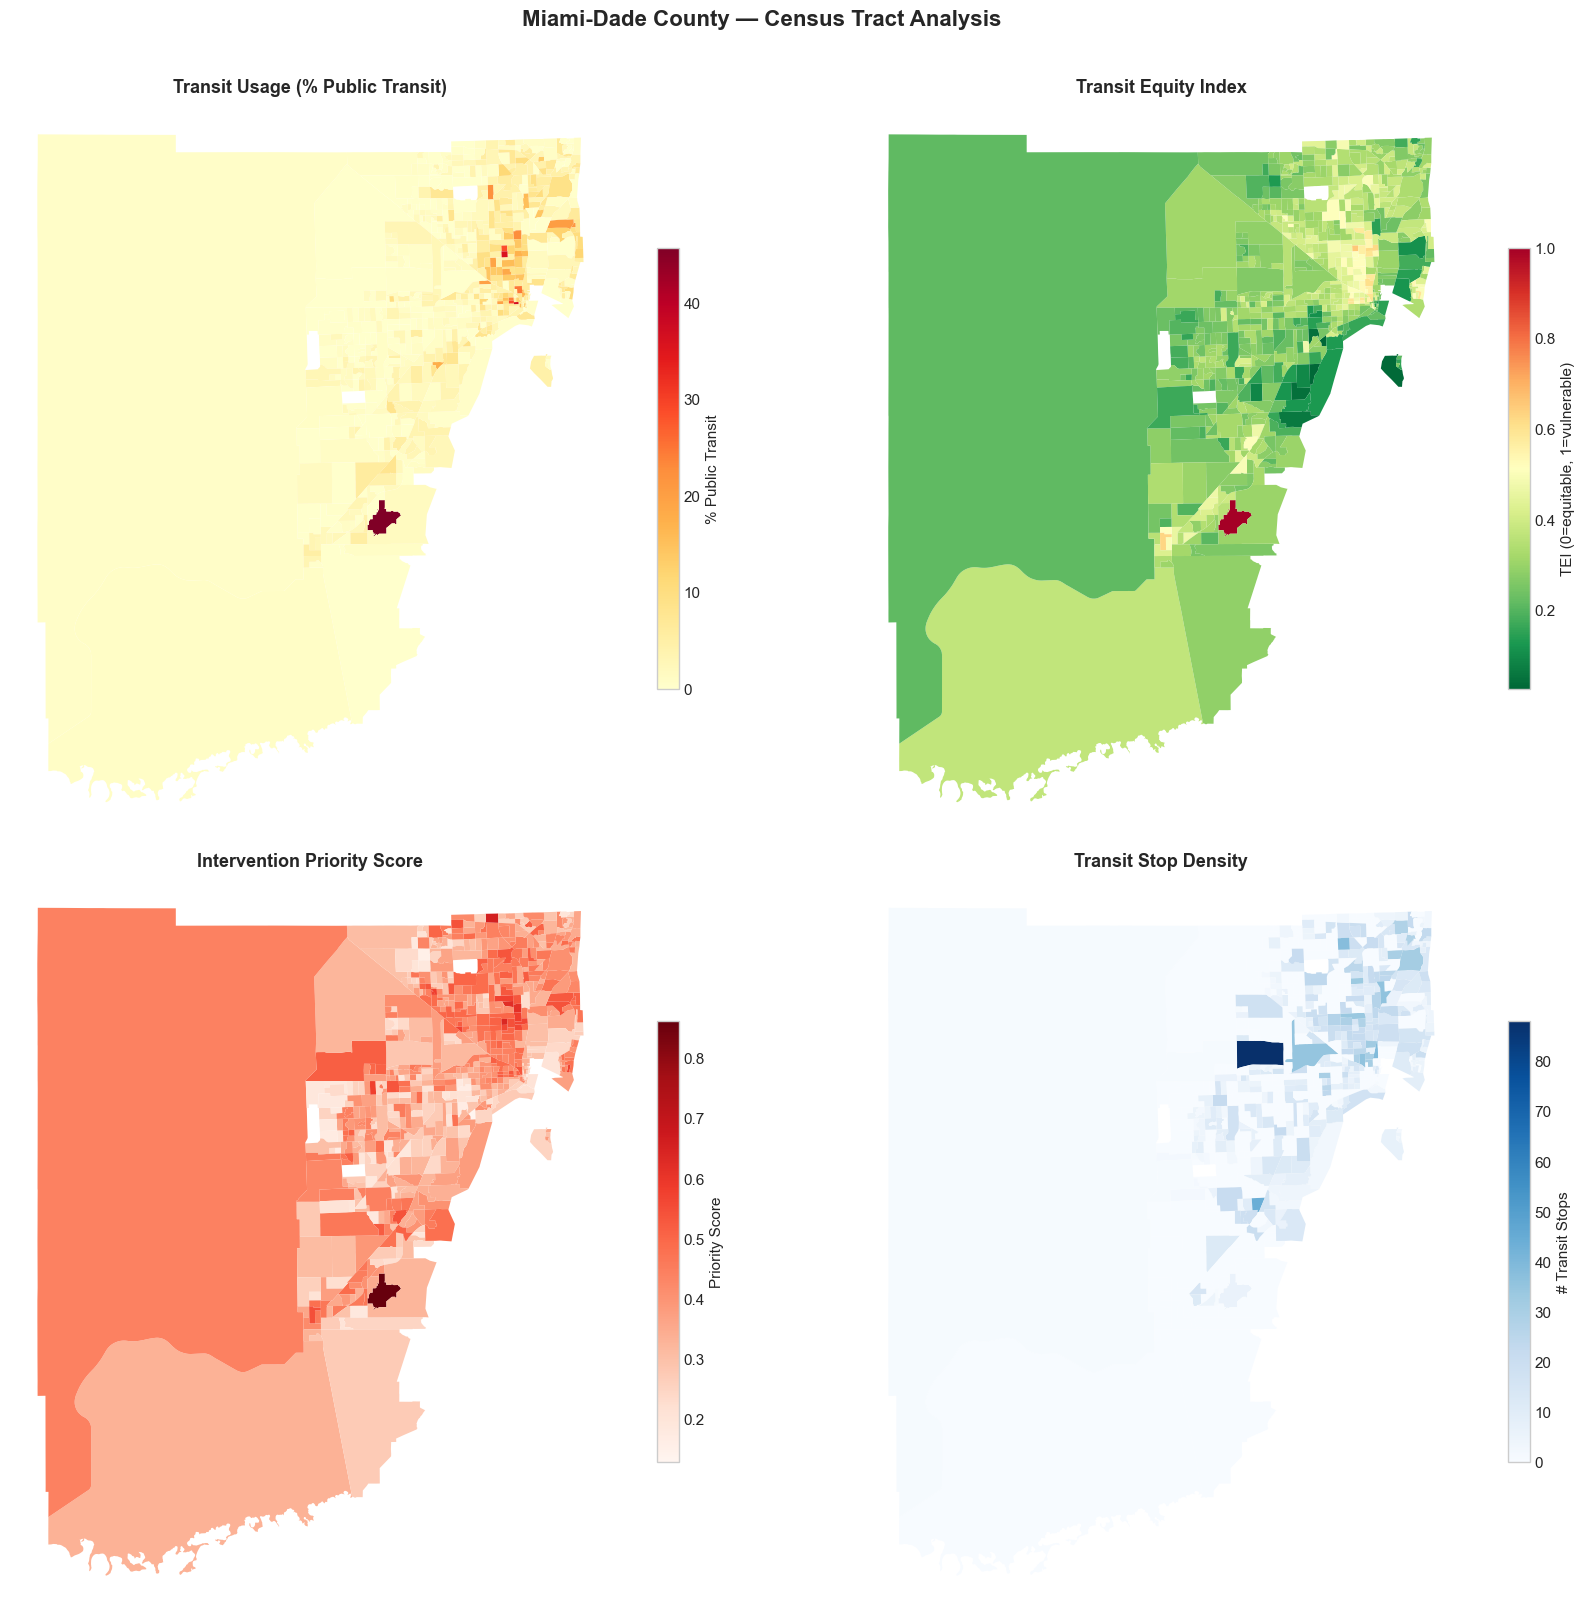

In [44]:
# ============================================================
# STATIC MATPLOTLIB MAPS (4 panels)
# ============================================================

if tracts_geo is not None:
    # Select columns for merge — filter to only those that exist in df_model
    map_cols = ['GEOID', 'pct_public_transit', 'transit_equity_index',
                'intervention_priority_score', 'predicted_transit_usage',
                'supply_demand_mismatch', 'n_stops', 'median_household_income',
                'vulnerability_tier', 'priority_rank']
    map_cols = [c for c in map_cols if c in df_model.columns]

    map_data = tracts_geo.merge(
        df_model[map_cols],
        on='GEOID', how='inner'
    )
    print(f'✅ Merged: {len(map_data)} tracts with geometry + model data')
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    
    map_data.plot(column='pct_public_transit', cmap='YlOrRd', legend=True, ax=axes[0,0],
                  legend_kwds={'label': '% Public Transit', 'shrink': 0.6})
    axes[0,0].set_title('Transit Usage (% Public Transit)', fontsize=13, fontweight='bold')
    axes[0,0].axis('off')
    
    map_data.plot(column='transit_equity_index', cmap='RdYlGn_r', legend=True, ax=axes[0,1],
                  legend_kwds={'label': 'TEI (0=equitable, 1=vulnerable)', 'shrink': 0.6})
    axes[0,1].set_title('Transit Equity Index', fontsize=13, fontweight='bold')
    axes[0,1].axis('off')
    
    map_data.plot(column='intervention_priority_score', cmap='Reds', legend=True, ax=axes[1,0],
                  legend_kwds={'label': 'Priority Score', 'shrink': 0.6})
    axes[1,0].set_title('Intervention Priority Score', fontsize=13, fontweight='bold')
    axes[1,0].axis('off')
    
    map_data.plot(column='n_stops', cmap='Blues', legend=True, ax=axes[1,1],
                  legend_kwds={'label': '# Transit Stops', 'shrink': 0.6})
    axes[1,1].set_title('Transit Stop Density', fontsize=13, fontweight='bold')
    axes[1,1].axis('off')
    
    plt.suptitle('Miami-Dade County — Census Tract Analysis',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('Sprint2_choropleth_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('⚠️ Skipping static maps — install geopandas + folium')

In [48]:
# ============================================================
# INTERACTIVE FOLIUM MAP
# ============================================================

if tracts_geo is not None and HAS_GEO:
    try:
        map_data_wgs = map_data.to_crs(epsg=4326)
        
        m = folium.Map(location=[25.76, -80.37], zoom_start=10, tiles='cartodbpositron')
        
        folium.Choropleth(
            geo_data=map_data_wgs.__geo_interface__,
            data=map_data_wgs,
            columns=['GEOID', 'intervention_priority_score'],
            key_on='feature.properties.GEOID',
            fill_color='YlOrRd',
            fill_opacity=0.7,
            line_opacity=0.2,
            legend_name='Intervention Priority Score'
        ).add_to(m)
        
        # Tooltip layer for interactivity
        style_fn = lambda x: {
            'fillColor': '#ffffff', 'color': '#000000',
            'fillOpacity': 0.001, 'weight': 0.1
        }
        highlight_fn = lambda x: {
            'fillColor': '#000000', 'color': '#000000',
            'fillOpacity': 0.50, 'weight': 0.1
        }
        tooltip = folium.features.GeoJsonTooltip(
            fields=['NAMELSAD', 'pct_public_transit', 'transit_equity_index',
                    'intervention_priority_score', 'n_stops', 'priority_rank'],
            aliases=['Tract:', 'Transit Usage %:', 'Equity Index:',
                     'Priority Score:', '# Stops:', 'Priority Rank:'],
            style='background-color: white; color: #333; font-family: arial; '
                  'font-size: 12px; padding: 10px;'
        )
        folium.GeoJson(
            map_data_wgs,
            style_function=style_fn,
            highlight_function=highlight_fn,
            tooltip=tooltip
        ).add_to(m)
        
        Fullscreen().add_to(m)
        m.save('Sprint2_Interactive_Priority_Map.html')
        print('✅ Interactive map saved: Sprint2_Interactive_Priority_Map.html')
        display(m)
    except Exception as e:
        print(f'⚠️ Folium map error: {e}')
else:
    print('⚠️ Skipping interactive map')

✅ Interactive map saved: Sprint2_Interactive_Priority_Map.html


### Interpretation — Choropleth Maps

The four-panel static map visualizes the spatial distribution of key metrics:

- **Transit Usage (top-left):** Darker red = higher % of workers using public transit. Expect
  concentration along the Metrorail corridor (north-south through downtown Miami) and bus-heavy areas.
- **Transit Equity Index (top-right):** Red/dark = most vulnerable tracts. Clusters of vulnerability
  in areas like Liberty City, Little Haiti, Overtown, and Homestead indicate persistent inequity.
- **Priority Score (bottom-left):** The composite intervention ranking. Darkest red = most urgent.
  These are the tracts where the Deloitte recommendation should focus.
- **Stop Density (bottom-right):** Blue intensity = more transit stops. Compare with the priority map —
  high-priority tracts with few stops are the clearest case for adding new routes.

The **interactive Folium map** (HTML file) lets you hover over any tract to see its exact metrics.
This is the recommended format for Deloitte stakeholder presentations.

## 11. Sprint 2 Summary & Key Findings

In [46]:
print('='*90)
print('SPRINT 2: FEATURE ENGINEERING & MODELING — KEY FINDINGS (v2)')
print('='*90)

best_row = results_df.iloc[0]

print(f'''
📊 DATA SOURCES INTEGRATED
━━━━━━━━━━━━━━━━━━━━━━━━━━
• Source 1 — Census ACS (DP03+DP04+DP05): {census.shape[1]-2} variables across 707 tracts
• Source 2 — GTFS Transit: {gtfs.shape[1]-1} transit infrastructure variables
• Source 3 — ArcGIS Accessibility: {arcgis.shape[1]-1} job accessibility metrics

🔧 FEATURE ENGINEERING (Issues #19-#22)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• {len(candidate_features)} candidates → {len(selected_features)} selected
• ⚠️ Removed leaky features: car_dependency, transit_mode_share, transit_need_score
• New features: supply_demand_mismatch, severe_rent_burden, diversity_index

🤖 BEST MODEL: {best_row["Model"]}
━━━━━━━━━━━━━━━━━━━━━━━━
• Test R²: {best_row["Test R²"]:.3f}
• Spatial CV R²: {best_row["Spatial CV R² (mean)"]:.3f} ± {best_row["Spatial CV R² (std)"]:.3f}
• RMSE: {best_row["Test RMSE"]:.2f} percentage points
• Overfit Gap: {best_row["Overfit Gap"]:.3f}

🔑 TOP DRIVERS OF TRANSIT USAGE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━''')
for _, r in fi_gb.head(5).iterrows():
    print(f'  • {r["Feature"]}: {r["Importance"]:.4f}')

print(f'''
🗺️ GEOGRAPHIC PRIORITIES
━━━━━━━━━━━━━━━━━━━━━━━━
• {len(df_model)} tracts ranked by intervention priority
• Priority = Equity vulnerability (40%) + Supply-demand mismatch (30%) + Accessibility gap (30%)

📌 NEXT STEPS → Sprint 3
━━━━━━━━━━━━━━━━━━━━━━━━
1. Graph network (stops = nodes, routes = edges)
2. GNN simulations on priority tracts
3. Streamlit dashboard with interactive maps
''')

SPRINT 2: FEATURE ENGINEERING & MODELING — KEY FINDINGS (v2)

📊 DATA SOURCES INTEGRATED
━━━━━━━━━━━━━━━━━━━━━━━━━━
• Source 1 — Census ACS (DP03+DP04+DP05): 47 variables across 707 tracts
• Source 2 — GTFS Transit: 10 transit infrastructure variables
• Source 3 — ArcGIS Accessibility: 19 job accessibility metrics

🔧 FEATURE ENGINEERING (Issues #19-#22)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• 28 candidates → 25 selected
• ⚠️ Removed leaky features: car_dependency, transit_mode_share, transit_need_score
• New features: supply_demand_mismatch, severe_rent_burden, diversity_index

🤖 BEST MODEL: XGBoost
━━━━━━━━━━━━━━━━━━━━━━━━
• Test R²: 0.275
• Spatial CV R²: -0.099 ± 0.626
• RMSE: 3.98 percentage points
• Overfit Gap: 0.717

🔑 TOP DRIVERS OF TRANSIT USAGE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  • transit_equity_index: 0.2997
  • hh_no_vehicle_pct: 0.1852
  • service_sector_share: 0.0710
  • renter_occupied_pct: 0.0700
  • per_capita_income: 0.0593

🗺️ GEOGRAPHIC PRIORITIES
━━━━━━━━━━━━━━━━━━━

## 12. Export Results for Sprint 3

We export two CSV files for downstream use:
- **Zone Priority Ranking** — Top columns for Sprint 3 dashboard and GNN simulations
- **Full Engineered Features** — Complete feature set for further modeling

In [47]:
# ============================================================
# EXPORT FOR SPRINT 3
# ============================================================

export_cols = [
    'priority_rank', 'tract_fips', 'GEOID', 'NAME', 'pct_public_transit',
    'predicted_transit_usage', 'transit_equity_index', 'supply_demand_mismatch',
    'accessibility_gap', 'intervention_priority_score', 'vulnerability_tier',
    'n_stops', 'n_trips_total', 'median_household_income'
]
df_model[[c for c in export_cols if c in df_model.columns]].sort_values('priority_rank') \
    .to_csv('Sprint2_Zone_Priority_Ranking.csv', index=False)

df_model.to_csv('Sprint2_Engineered_Features.csv', index=False)

print('✅ Sprint2_Zone_Priority_Ranking.csv — Zone priorities for Sprint 3 dashboard')
print('✅ Sprint2_Engineered_Features.csv — Full feature set for Sprint 3 modeling')
if tracts_geo is not None:
    print('✅ Sprint2_Interactive_Priority_Map.html — Interactive Folium map')
print('✅ Sprint2_choropleth_maps.png — Static 4-panel map')
print('\n🎯 Sprint 2 Complete!')

✅ Sprint2_Zone_Priority_Ranking.csv — Zone priorities for Sprint 3 dashboard
✅ Sprint2_Engineered_Features.csv — Full feature set for Sprint 3 modeling
✅ Sprint2_Interactive_Priority_Map.html — Interactive Folium map
✅ Sprint2_choropleth_maps.png — Static 4-panel map

🎯 Sprint 2 Complete!
